# Sensitivity & Clustering Analysis

- Providing sensitivity curves over decay parameters α, β₁, β₂ and window size.
- Comparing distance-based novelty formulations: minimum distance, k-NN average distance, and density-based (kernel) novelty.
- Performing clustering (KMeans, DBSCAN) to examine embedding structure and integrating cluster-derived novelty.
- Fusing scores and evaluating robustness (ROC-AUC, PR-AUC, F1).



#### 1. Load Dependencies and Utility Imports

In [1]:
import os, json, math, itertools
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.neighbors import NearestNeighbors, KDTree
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sns.set_context('talk')
plt.style.use('seaborn-v0_8')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Placeholder for potential ResultAnalysis integration if available as module
try:
    from ResultAnalysis import ResultAnalysis  # if a python module exists
except ImportError:
    class ResultAnalysis:
        def __init__(self, config):
            self.config = config
        def standardize_long_format(self, df, value_cols, var_name='metric', value_name='value'):
            return df.melt(id_vars=[c for c in df.columns if c not in value_cols], value_vars=value_cols,
                           var_name=var_name, value_name=value_name)
        def summarize(self, df, group_cols, value_col):
            return df.groupby(group_cols)[value_col].agg(['mean','std','count']).reset_index()

print('Imports complete.')

Imports complete.


#### 2. Configure Paths and Initialize ResultAnalysis

In [4]:
DATA_DIR = '../Dataset/SMT_Dataset'
EMBED_PATH = '../saved_models/STCRL_transfer_learning/embeddings/embedded_trajectories.csv'
TRAJ_PATH = os.path.join(DATA_DIR, 'preprocessed_human_smt_dataset.csv')
OUT_DIR = './sensitivity_clustering_artifacts'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
META_DIR = os.path.join(OUT_DIR, 'metrics')
for d in [OUT_DIR, FIG_DIR, META_DIR]:
    os.makedirs(d, exist_ok=True)

analysis = ResultAnalysis(config={'output_dir': OUT_DIR})
print('Paths configured.')

Paths configured.


#### 3. Load and Preprocess Data

In [5]:
# Load trajectories and embeddings
traj_df = pd.read_csv(TRAJ_PATH)
emb_df = pd.read_csv(EMBED_PATH)

# Expect column 'trajectory_embedding_multi_loss'
if 'trajectory_embedding_multi_loss' not in emb_df.columns:
    raise ValueError('Embedding column missing in embeddings file.')

# Merge on index
merged = pd.merge(traj_df, emb_df[['trajectory_embedding_multi_loss']], left_index=True, right_index=True, how='inner')

# Parse embeddings (space-separated inside brackets)
def parse_embedding(s):
    try:
        s = s.strip('[]')
        return np.fromstring(s, sep=' ')
    except Exception:
        return np.array([])

merged['embedding'] = merged['trajectory_embedding_multi_loss'].apply(parse_embedding)
merged = merged[merged['embedding'].apply(lambda x: x.size > 0)].copy()

# Basic performance columns check
required_cols = ['completion_time','rmsd','is_success']
missing = [c for c in required_cols if c not in merged.columns]
if missing:
    print('Warning: missing performance columns:', missing)

# Standardize success to binary 0/1
if 'is_success' in merged.columns:
    merged['is_success'] = merged['is_success'].astype(int)

# Build embedding matrix
E = np.vstack(merged['embedding'].values)
print('Embeddings shape:', E.shape)

# Scale embeddings for clustering later
scaler = StandardScaler()
E_scaled = scaler.fit_transform(E)

# Optional PCA for speed
pca = PCA(n_components=min(50, E_scaled.shape[1]))
E_pca = pca.fit_transform(E_scaled)

print('Preprocessing complete.')

Embeddings shape: (16309, 128)
Preprocessing complete.


#### 4. Define Decay / Exploration Weight Functions (alpha, beta1, beta2)

In [24]:
# Original temporal decay (single beta) retained if needed elsewhere:
# Temporal decay: w_t = exp(-beta * delta_t)
# Distance kernel: K(r) = exp(-alpha * r)
# New exploration weight per trial index i: W_i = beta1 + beta2 * exp(-i * alpha)

import numpy as np

def temporal_decay(deltas, beta):
    return np.exp(-beta * deltas)

def distance_kernel(dists, alpha):
    return np.exp(-alpha * dists)

def exploration_weight(idx: int, alpha: float, beta1: float, beta2: float) -> float:
    return beta1 + beta2 * np.exp(-idx * alpha)

# 5. Implement Distance Metrics (Min vs KNN Average)
# Assume embeddings E_pca as feature space for distances.

kdtree = KDTree(E_pca)

def min_distance(point, window_idx):
    dists, _ = kdtree.query(E_pca[window_idx], k=1)
    return float(dists.min())

def knn_avg_distance(point, window_idx, k=10):
    dists, _ = kdtree.query(E_pca[window_idx], k=min(k, len(window_idx)))
    return float(dists.mean())

# 6. Density-based Novelty Score (kept for completeness)
# rho(x) = sum_{i in W} exp(-alpha * ||x - x_i||) * w_{t_i}; novelty = 1/(rho+eps)
# For temporal weights in density we still use exp(-alpha * delta_t) to emphasize recency.

def density_novelty(point_vec, window_vectors, alpha, temporal_weights, eps=1e-9):
    dists = np.linalg.norm(window_vectors - point_vec, axis=1)
    spatial = distance_kernel(dists, alpha)
    rho = np.sum(spatial * temporal_weights)
    return 1.0 / (rho + eps)

print('Decay and exploration weight functions updated.')

Decay and exploration weight functions updated.


#### 5. Sensitivity Grid Definition (updated with beta1, beta2)

In [25]:
alphas = [0.05, 0.1, 0.2, 0.3, 0.5]
beta1s = [0.1, 0.3, 0.5, 0.7, 0.9]
beta2s = [0.1, 0.3, 0.5, 0.7, 0.9]
#window_sizes = [32, 64, 128, 256, 512]
window_sizes = [6, 12, 24, 48, 72, 96, 120, 240, 480]
knn_k = 10

# Performance targets
completion = merged.get('completion_time', pd.Series(np.zeros(len(merged)))).values
rmsd = merged.get('rmsd', pd.Series(np.zeros(len(merged)))).values
success = merged.get('is_success', pd.Series(np.zeros(len(merged)))).values

# 8. Run Sensitivity Sweep with Exploration Formula:
# Exploration(e_i) = min_{j<i} Dist(e_i, e_j) * (beta1 + beta2 * exp(-i * alpha))
# We apply same weighting to the kNN average distance variant for comparison.
results = []
E_full = E_pca  # feature space
T = len(E_full)
indices = np.arange(T)

for alpha in alphas:
    for beta1 in beta1s:
        for beta2 in beta2s:
            for wsize in window_sizes:
                min_scores = []
                knn_scores = []
                dens_scores = []  # retained but now unused in curves
                for idx in range(T):
                    start = max(0, idx - wsize)
                    window_idx = indices[start:idx]
                    if len(window_idx) == 0:
                        min_scores.append(np.nan)
                        knn_scores.append(np.nan)
                        dens_scores.append(np.nan)
                        continue
                    point = E_full[idx]
                    window_vecs = E_full[window_idx]
                    # Raw distances to window
                    dists = np.linalg.norm(window_vecs - point, axis=1)
                    d_min = dists.min()
                    k_local = min(knn_k, len(window_idx))
                    d_knn = np.sort(dists)[:k_local].mean()
                    weight = (beta1 + beta2 * np.exp(-idx * alpha))
                    # Exploration scores
                    min_scores.append(d_min * weight)
                    knn_scores.append(d_knn * weight)
                    # Density novelty (unchanged, still optional): use raw distance kernel with temporal index weight
                    temporal_w = np.exp(-np.arange(len(window_idx))[::-1] * alpha)
                    dens_scores.append(density_novelty(point, window_vecs, alpha, temporal_w))

                ms = np.array(min_scores)
                ks = np.array(knn_scores)
                ds = np.array(dens_scores)

                valid_mask = ~np.isnan(ms)
                if valid_mask.sum() < 10:
                    continue
                comp_v = completion[valid_mask]
                rmsd_v = rmsd[valid_mask]
                success_v = success[valid_mask]
                ms_v, ks_v, ds_v = ms[valid_mask], ks[valid_mask], ds[valid_mask]

                def safe_corr(a, b):
                    try:
                        return pearsonr(a, b)[0]
                    except Exception:
                        return np.nan
                res_row = {
                    'alpha': alpha, 'beta1': beta1, 'beta2': beta2, 'window': wsize,
                    'corr_min_completion': safe_corr(ms_v, comp_v),
                    'corr_knn_completion': safe_corr(ks_v, comp_v),
                    'corr_dens_completion': safe_corr(ds_v, comp_v),
                    'corr_min_rmsd': safe_corr(ms_v, rmsd_v),
                    'corr_knn_rmsd': safe_corr(ks_v, rmsd_v),
                    'corr_dens_rmsd': safe_corr(ds_v, rmsd_v)
                }
                try:
                    # Higher exploration score => more novel, invert for typical success detection
                    res_row['auc_min_success'] = roc_auc_score(success_v, -ms_v)
                    res_row['auc_knn_success'] = roc_auc_score(success_v, -ks_v)
                    res_row['auc_dens_success'] = roc_auc_score(success_v, -ds_v)
                except Exception:
                    res_row['auc_min_success'] = np.nan
                    res_row['auc_knn_success'] = np.nan
                    res_row['auc_dens_success'] = np.nan
                results.append(res_row)

sweep_df = pd.DataFrame(results)
print('Sensitivity sweep complete (with beta1, beta2). Rows:', len(sweep_df))
sweep_df.head()

Sensitivity sweep complete (with beta1, beta2). Rows: 1125


,alpha,beta1,beta2,window,corr_min_completion,corr_knn_completion,corr_dens_completion,corr_min_rmsd,corr_knn_rmsd,corr_dens_rmsd,auc_min_success,auc_knn_success,auc_dens_success
0,0.05,0.1,0.1,6,0.037797,-0.056074,-0.025880,0.003076,-0.068177,-0.046480,0.480059,0.460360,0.442297
1,0.05,0.1,0.1,12,0.119392,-0.099690,-0.021092,0.052582,-0.097442,-0.042959,0.508127,0.416124,0.436180
2,0.05,0.1,0.1,24,0.169391,-0.029913,-0.016989,0.084248,-0.040326,-0.038286,0.529051,0.419371,0.432005
3,0.05,0.1,0.1,48,0.204006,0.075247,-0.015961,0.106356,0.029920,-0.034819,0.542991,0.458880,0.426605
4,0.05,0.1,0.1,72,0.213955,0.117112,-0.016017,0.112362,0.054325,-0.034132,0.546270,0.477010,0.424254


#### 6. Sensitivity Curves (3 subplots: Success, RMSD, Completion) comparing MIN vs KNN

Best (alpha,beta1,beta2) for MIN by AUC: (0.05, 0.1, 0.9)
Best (alpha,beta1,beta2) for KNN by AUC: (0.05, 0.1, 0.9)


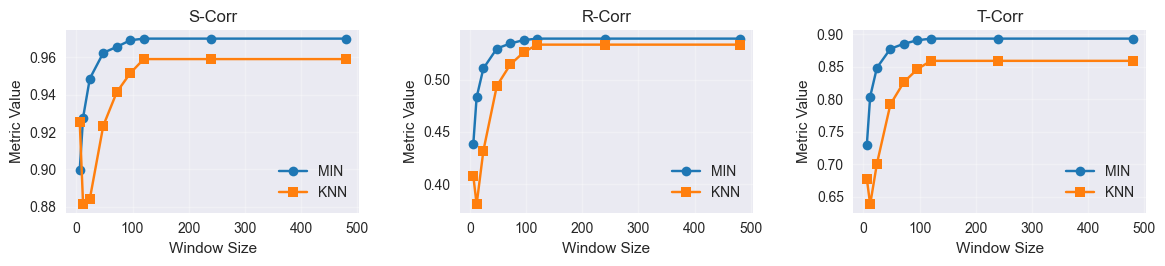

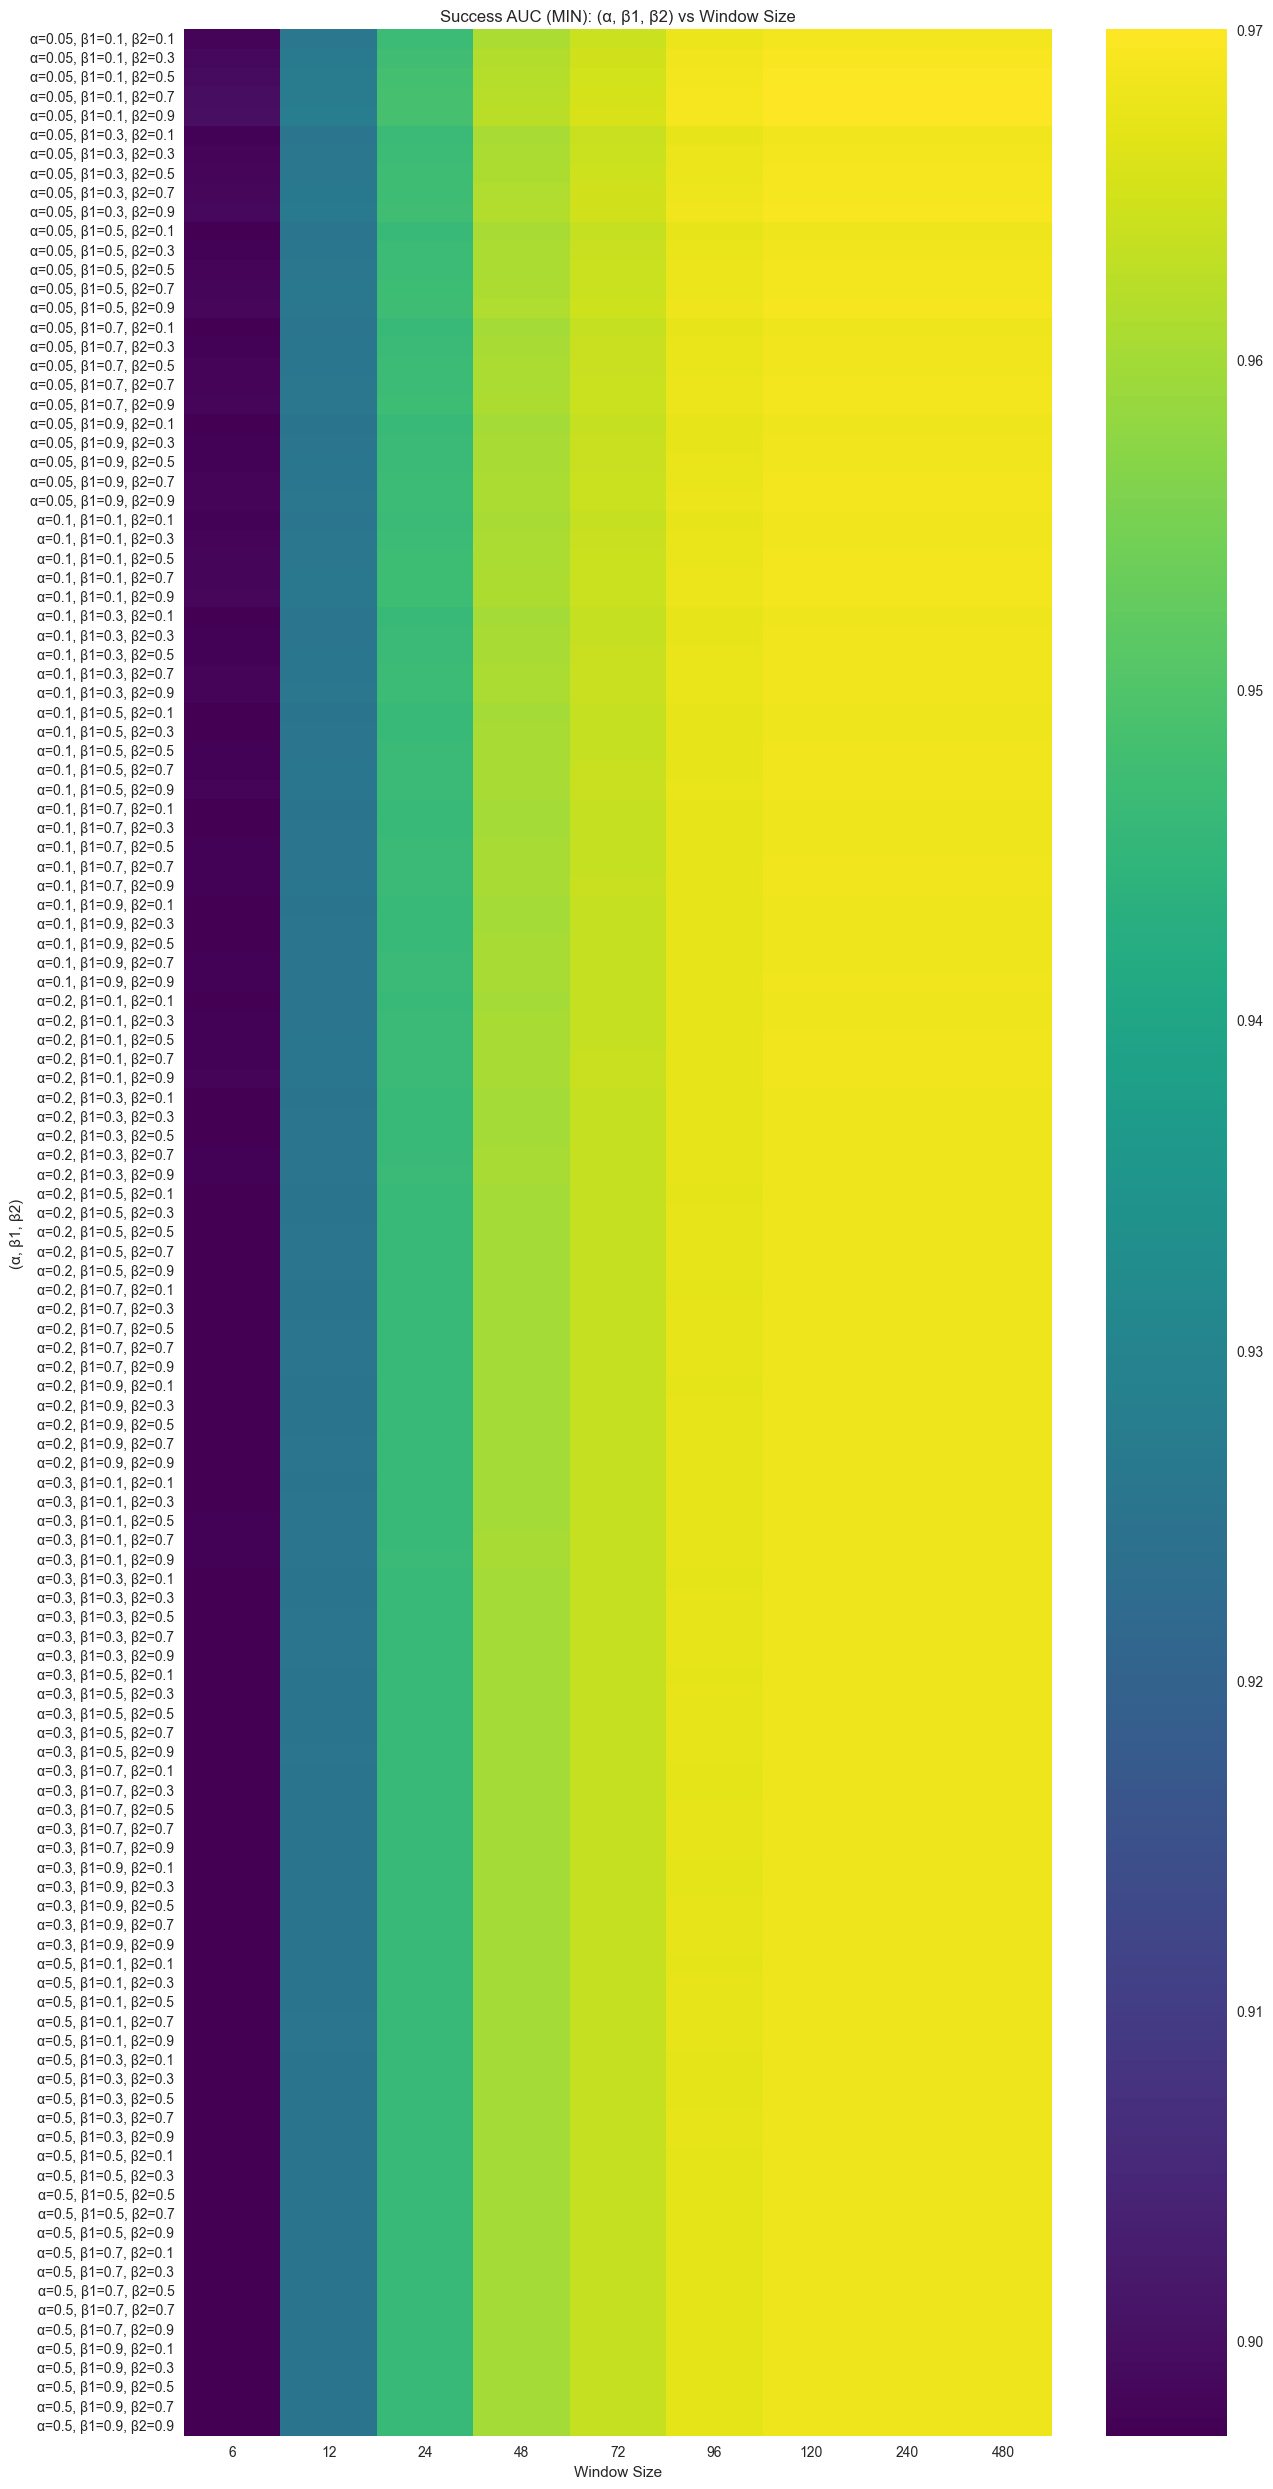

Updated sensitivity curves and triple-parameter heatmap saved.


In [50]:
def best_params(sdf: pd.DataFrame, auc_col: str) -> tuple:
    tmp = sdf.groupby(['alpha','beta1','beta2'])[auc_col].mean().reset_index()
    best_row = tmp.loc[tmp[auc_col].idxmax()]
    return float(best_row['alpha']), float(best_row['beta1']), float(best_row['beta2'])

best_alpha_min, best_beta1_min, best_beta2_min = best_params(sweep_df, 'auc_min_success')
best_alpha_knn, best_beta1_knn, best_beta2_knn = best_params(sweep_df, 'auc_knn_success')
print(f"Best (alpha,beta1,beta2) for MIN by AUC: ({best_alpha_min}, {best_beta1_min}, {best_beta2_min})")
print(f"Best (alpha,beta1,beta2) for KNN by AUC: ({best_alpha_knn}, {best_beta1_knn}, {best_beta2_knn})")

min_slice = sweep_df[(sweep_df['alpha']==best_alpha_min)&(sweep_df['beta1']==best_beta1_min)&(sweep_df['beta2']==best_beta2_min)]
knn_slice = sweep_df[(sweep_df['alpha']==best_alpha_knn)&(sweep_df['beta1']==best_beta1_knn)&(sweep_df['beta2']==best_beta2_knn)]

metrics_triplets = [
    ('S-Corr', 'auc_min_success', 'auc_knn_success'),
    ('R-Corr', 'corr_min_rmsd', 'corr_knn_rmsd'),
    ('T-Corr', 'corr_min_completion', 'corr_knn_completion')
]

fig, axes = plt.subplots(1, 3, figsize=(12,3), sharey=False)
for ax, (title, min_col, knn_col) in zip(axes, metrics_triplets):
    # MIN line
    series_min = min_slice.groupby('window')[min_col].mean()
    ax.plot(series_min.index, series_min.values, marker='o', label='MIN', color='#1f77b4')
    # KNN line
    series_knn = knn_slice.groupby('window')[knn_col].mean()
    ax.plot(series_knn.index, series_knn.values, marker='s', label='KNN', color='#ff7f0e')
    ax.set_title(f"{title}")
    ax.set_xlabel('Window Size')
    ax.set_ylabel('Metric Value')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'sensitivity_curves_min_vs_knn_three_metrics.png'), dpi=200, bbox_inches='tight')
plt.show()

# Heatmap: (alpha,beta1,beta2) vs Window for Success AUC (MIN)
heat_df = sweep_df.copy()
heat_df['param_triple'] = heat_df.apply(lambda r: f"α={r['alpha']}, β1={r['beta1']}, β2={r['beta2']}", axis=1)
heat_pivot = heat_df.pivot_table(index='param_triple', columns='window', values='auc_min_success', aggfunc='mean')
plt.figure(figsize=(14, max(6, 0.25*len(heat_pivot))))
sns.heatmap(heat_pivot, annot=False, cmap='viridis')
plt.title('Success AUC (MIN): (α, β1, β2) vs Window Size')
plt.xlabel('Window Size')
plt.ylabel('(α, β1, β2)')
plt.savefig(os.path.join(FIG_DIR, 'heatmap_alpha_beta1_beta2_vs_window_min_auc.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Updated sensitivity curves and triple-parameter heatmap saved.')

#### 7. Distance Metrics Comparative Evaluation (ROC-AUC, PR-AUC, F1)
 Use representative parameters = best (alpha,beta1,beta2) by AUC for each method and best window per method.

Representative MIN params: α=0.05, β1=0.1, β2=0.9, window=120
Representative KNN params: α=0.05, β1=0.1, β2=0.9, window=120
Representative metric performance:
                   metric   roc_auc    pr_auc   best_f1  alpha  beta1  beta2  \
0            min_dist_rep  0.552134  0.540289  0.699425   0.05    0.1    0.9   
1   knn_avg_rep_minParams  0.496200  0.502618  0.692673   0.05    0.1    0.9   
2  min_dist_rep_knnParams  0.552134  0.540289  0.699425   0.05    0.1    0.9   
3             knn_avg_rep  0.496200  0.502618  0.692673   0.05    0.1    0.9   

   window  
0     120  
1     120  
2     120  
3     120  
Running clustering...
     algo    k  silhouette  mean_purity  eps
0  KMeans  3.0    0.478900     0.962428  NaN
1  KMeans  5.0    0.405406     0.982313  NaN
2  KMeans  7.0    0.290197     0.971298  NaN
3  DBSCAN  NaN    0.361061     1.000000  0.5
4  DBSCAN  NaN    0.670152     0.999547  1.0
5  DBSCAN  NaN    0.253241     0.998204  1.5
Generating TSNE projection...


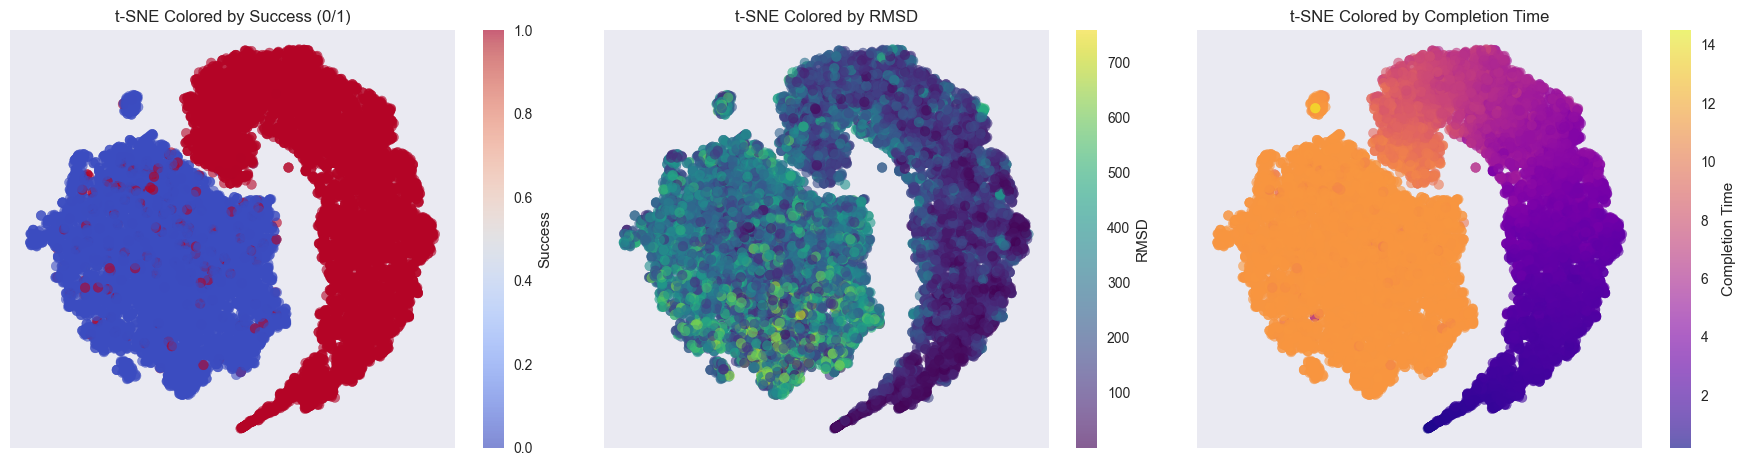

Fusing scores...
Fusion performance added.
Artifacts exported with updated parameter triples.


In [51]:
min_ab_slice = sweep_df[(sweep_df['alpha']==best_alpha_min)&(sweep_df['beta1']==best_beta1_min)&(sweep_df['beta2']==best_beta2_min)]
knn_ab_slice = sweep_df[(sweep_df['alpha']==best_alpha_knn)&(sweep_df['beta1']==best_beta1_knn)&(sweep_df['beta2']==best_beta2_knn)]

best_window_min = int(min_ab_slice.loc[min_ab_slice['auc_min_success'].idxmax(), 'window']) if not min_ab_slice.empty else 128
best_window_knn = int(knn_ab_slice.loc[knn_ab_slice['auc_knn_success'].idxmax(), 'window']) if not knn_ab_slice.empty else 128

print(f"Representative MIN params: α={best_alpha_min}, β1={best_beta1_min}, β2={best_beta2_min}, window={best_window_min}")
print(f"Representative KNN params: α={best_alpha_knn}, β1={best_beta1_knn}, β2={best_beta2_knn}, window={best_window_knn}")

# Recompute exploration vectors for representative MIN and KNN parameter sets
E_full = E_pca
T = len(E_full)
indices = np.arange(T)

def compute_exploration_vectors(alpha, beta1, beta2, wsize):
    min_vec = []
    knn_vec = []
    for idx in range(T):
        start = max(0, idx - wsize)
        window_idx = indices[start:idx]
        if len(window_idx) == 0:
            min_vec.append(np.nan); knn_vec.append(np.nan); continue
        point = E_full[idx]
        window_vecs = E_full[window_idx]
        dists = np.linalg.norm(window_vecs - point, axis=1)
        d_min = dists.min()
        k_local = min(knn_k, len(window_idx))
        d_knn = np.sort(dists)[:k_local].mean()
        weight = (beta1 + beta2 * np.exp(-idx * alpha))
        min_vec.append(d_min * weight)
        knn_vec.append(d_knn * weight)
    return np.array(min_vec), np.array(knn_vec)

ms_min, ks_min = compute_exploration_vectors(best_alpha_min, best_beta1_min, best_beta2_min, best_window_min)
ms_knn, ks_knn = compute_exploration_vectors(best_alpha_knn, best_beta1_knn, best_beta2_knn, best_window_knn)

# Evaluate success metrics for each representative set
from sklearn.metrics import precision_recall_curve

success_v = success  # same length T

def eval_scores(raw, invert=True):
    sc = -raw if invert else raw
    try:
        roc = roc_auc_score(success_v[~np.isnan(raw)], sc[~np.isnan(raw)])
        pr = average_precision_score(success_v[~np.isnan(raw)], sc[~np.isnan(raw)])
        best_f1 = 0
        sc_valid = sc[~np.isnan(raw)]
        succ_valid = success_v[~np.isnan(raw)]
        for th in np.quantile(sc_valid, np.linspace(0.05,0.95,15)):
            preds = (sc_valid >= th).astype(int)
            if preds.sum() == 0: continue
            f1 = f1_score(succ_valid, preds)
            best_f1 = max(best_f1, f1)
        return roc, pr, best_f1
    except Exception:
        return np.nan, np.nan, np.nan

metrics_rows = []
roc, pr, bf1 = eval_scores(ms_min, invert=True)
metrics_rows.append({'metric':'min_dist_rep', 'roc_auc':roc, 'pr_auc':pr, 'best_f1':bf1, 'alpha':best_alpha_min, 'beta1':best_beta1_min, 'beta2':best_beta2_min, 'window':best_window_min})
roc, pr, bf1 = eval_scores(ks_min, invert=True)
metrics_rows.append({'metric':'knn_avg_rep_minParams', 'roc_auc':roc, 'pr_auc':pr, 'best_f1':bf1, 'alpha':best_alpha_min, 'beta1':best_beta1_min, 'beta2':best_beta2_min, 'window':best_window_min})
roc, pr, bf1 = eval_scores(ms_knn, invert=True)
metrics_rows.append({'metric':'min_dist_rep_knnParams', 'roc_auc':roc, 'pr_auc':pr, 'best_f1':bf1, 'alpha':best_alpha_knn, 'beta1':best_beta1_knn, 'beta2':best_beta2_knn, 'window':best_window_knn})
roc, pr, bf1 = eval_scores(ks_knn, invert=True)
metrics_rows.append({'metric':'knn_avg_rep', 'roc_auc':roc, 'pr_auc':pr, 'best_f1':bf1, 'alpha':best_alpha_knn, 'beta1':best_beta1_knn, 'beta2':best_beta2_knn, 'window':best_window_knn})

perf_df = pd.DataFrame(metrics_rows)
print('Representative metric performance:')
print(perf_df)
perf_df.to_csv(os.path.join(META_DIR,'representative_metric_performance.csv'), index=False)

# 11. Clustering (KMeans & DBSCAN)
print('Running clustering...')
clust_results = []
for k in [3,5,7]:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    labels = km.fit_predict(E_pca)
    sil = silhouette_score(E_pca, labels)
    purity = []
    for c in range(k):
        mask = (labels==c)
        if mask.sum() == 0: continue
        vals = success[mask]
        maj = max(vals.mean(), 1-vals.mean())
        purity.append(maj)
    clust_results.append({'algo':'KMeans','k':k,'silhouette':sil,'mean_purity':np.mean(purity)})
for eps in [0.5,1.0,1.5]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(E_pca)
    core_mask = labels!=-1
    if len(set(labels[core_mask]))>1:
        sil = silhouette_score(E_pca[core_mask], labels[core_mask])
    else:
        sil = np.nan
    purities = []
    for c in set(labels):
        if c==-1: continue
        mask = (labels==c)
        vals = success[mask]
        if mask.sum()==0: continue
        maj = max(vals.mean(),1-vals.mean())
        purities.append(maj)
    clust_results.append({'algo':'DBSCAN','eps':eps,'silhouette':sil,'mean_purity':np.mean(purities) if purities else np.nan})
clust_df = pd.DataFrame(clust_results)
print(clust_df)
clust_df.to_csv(os.path.join(META_DIR,'clustering_summary.csv'), index=False)

# 12. TSNE Visualization with three subplots (Success, RMSD, Completion Time)
print('Generating TSNE projection...')
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30)
E_tsne = tsne.fit_transform(E_pca)
vis_df = pd.DataFrame({'x':E_tsne[:,0],'y':E_tsne[:,1],'success':success, 'rmsd':rmsd, 'completion':completion})

fig, axes = plt.subplots(1,3, figsize=(18,5))
sc0 = axes[0].scatter(vis_df['x'], vis_df['y'], c=vis_df['success'], cmap='coolwarm', alpha=0.6)
axes[0].set_title('t-SNE Colored by Success (0/1)')
plt.colorbar(sc0, ax=axes[0], label='Success')

sc1 = axes[1].scatter(vis_df['x'], vis_df['y'], c=vis_df['rmsd'], cmap='viridis', alpha=0.6)
axes[1].set_title('t-SNE Colored by RMSD')
plt.colorbar(sc1, ax=axes[1], label='RMSD')

sc2 = axes[2].scatter(vis_df['x'], vis_df['y'], c=vis_df['completion'], cmap='plasma', alpha=0.6)
axes[2].set_title('t-SNE Colored by Completion Time')
plt.colorbar(sc2, ax=axes[2], label='Completion Time')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR,'tsne_multi_metrics.png'), dpi=200, bbox_inches='tight')
plt.show()

# 13. Score Fusion (min + knn + cluster) using MIN representative param set
print('Fusing scores...')
try:
    valid_min = ~np.isnan(ms_min)
    def normv(v, mask):
        v = v[mask]
        return (v - v.min())/(v.max()-v.min()+1e-9)
    ms_n = normv(ms_min, valid_min)
    ks_n = normv(ks_min, valid_min)
    cluster_labels = KMeans(n_clusters=5, random_state=RANDOM_SEED).fit_predict(E_pca)
    sizes = pd.Series(cluster_labels).value_counts()
    cluster_nov = np.array([1.0/(sizes[l]+1e-6) for l in cluster_labels])[valid_min]
    success_v_min = success_v[valid_min]
    gamma = np.array([0.4,0.4,0.2])
    fused = gamma[0]*ms_n + gamma[1]*ks_n + gamma[2]*cluster_nov
    fused_auc = roc_auc_score(success_v_min, fused)
    fused_pr = average_precision_score(success_v_min, fused)
    best_f1 = 0
    for th in np.quantile(fused, np.linspace(0.05,0.95,15)):
        preds = (fused>=th).astype(int)
        if preds.sum()==0: continue
        f1 = f1_score(success_v_min, preds)
        best_f1 = max(best_f1, f1)
    fusion_row = {'metric':'fused_min_knn_cluster','roc_auc':fused_auc,'pr_auc':fused_pr,'best_f1':best_f1,
                  'alpha':best_alpha_min,'beta1':best_beta1_min,'beta2':best_beta2_min,'window':best_window_min}
    perf_df = pd.concat([perf_df, pd.DataFrame([fusion_row])], ignore_index=True)
    perf_df.to_csv(os.path.join(META_DIR,'representative_metric_performance.csv'), index=False)
    print('Fusion performance added.')
except Exception as e:
    print('Fusion evaluation failed:', e)

summary = {
    'sweep_rows': int(len(sweep_df)),
    'best_params_min': {'alpha':best_alpha_min,'beta1':best_beta1_min,'beta2':best_beta2_min,'window':best_window_min},
    'best_params_knn': {'alpha':best_alpha_knn,'beta1':best_beta1_knn,'beta2':best_beta2_knn,'window':best_window_knn},
    'clustering': clust_results,
    'fusion_metrics': perf_df.to_dict(orient='records') if 'perf_df' in locals() else []
}
with open(os.path.join(META_DIR,'summary.json'),'w') as f:
    json.dump(summary, f, indent=2)

sweep_df.to_csv(os.path.join(META_DIR,'sensitivity_sweep.csv'), index=False)
print('Artifacts exported with updated parameter triples.')